In [42]:
import pandas as pd
import requests
import numpy as np
from bs4 import BeautifulSoup

In [43]:
url='https://www.myntra.com/skirts-women?rawQuery=skirts%20women'
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml"
}

session = requests.Session()
print("starting")
skirts = session.get(url,headers=headers,timeout=15)

print("done")
print(skirts.status_code)

starting
done
200


In [44]:
soup= BeautifulSoup(skirts.text,'lxml')

<!DOCTYPE html>
<html lang="en">
 <head>
  <title>
   Buy Trendy &amp; Stylish Skirts for Women Online in India (60% Off)
  </title>
  <meta content="#fffff" name="theme-color"/>
  <link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/>
  <link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/>
  <link href="https://www.facebook.com" rel="dns-prefetch preconnect"/>
  <link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/>
  <link href="/manifest.json" rel="manifest"/>
  <link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/>
  <link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" rel="appl
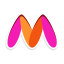

In [45]:
print(soup.prettify())

In [46]:
from selenium import webdriver
from bs4 import BeautifulSoup
import time
driver= webdriver.Chrome()

url = "https://www.myntra.com/skirts-women?rawQuery=skirts%20women"
driver.get(url)

time.sleep(10)
html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

items= soup.find_all('li',class_='product-base')
print(len(items))

50


In [47]:
print(items[0].prettify())

<li class="product-base" id="30146534">
 <div class="product-thumbShim">
 </div>
 <div class="product-ratingsContainer">
  <span>
   4.2
  </span>
  <span class="myntraweb-sprite product-starIcon index-productRatingsExcellentIcon sprites-productRatingsExcellentIcon">
  </span>
  <div class="product-ratingsCount">
   <div class="product-separator">
    |
   </div>
   <!-- react-text: 386 -->
   2.5k
   <!-- /react-text -->
  </div>
 </div>
 <a data-refreshpage="true" href="skirts/drape+and+dazzle/drape-and-dazzle-women-denim-front-slit-midi-a-line-skirt/30146534/buy" style="display: block;" target="_blank">
  <div class="product-imageSliderContainer">
   <div class="product-sliderContainer" style="display: block;">
    <div style="background: rgb(255, 242, 223);">
     <div style="height: 280px; width: 100%;">
      <picture class="img-responsive" draggable="false" style="width: 100%; height: 100%; display: block;">
       <source srcset="
    https://assets.myntassets.com/f_webp,dpr_1.

In [49]:
title=[]
rating=[]
rating_count=[]
brand=[]
price=[]
image_urls=[]
size=[]

for i in items:

    t = i.find('h4', class_='product-product')
    title.append(t.text.strip() if t else None)

    r = i.find('div', class_='product-ratingsContainer')
    rating.append(r.text.strip() if r else None)

    rc = i.find('div', class_='product-ratingsCount')
    rating_count.append(rc.text.strip() if rc else None)

    b = i.find('h3', class_='product-brand')
    brand.append(b.text.strip() if b else None)

    s = i.find('h4', class_='product-sizes')
    size.append(s.text.strip() if s else None)

    p = i.find('div', class_='product-price')
    price.append(p.text.strip() if p else None)

    img = i.find("img")
    if img:
        image_urls.append(img.get("src"))
    else:
        image_urls.append(None)

In [50]:
print(title[:3])
print(price[:3])
print(image_urls[:3])

['Front Slit Midi A-Line Skirt', 'Women Polyester Skirts', 'Women Polyester Skort Skirt']
['Rs. 675Rs. 2599(74% OFF)', 'Rs. 824Rs. 2499(67% OFF)', 'Rs. 1103Rs. 1599(31% OFF)']
['https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/30146534/2024/7/6/5782e23f-ccf7-4872-b443-692608a6d1651720271757045Skirts1.jpg', 'https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2026/APRIL/6/zDgQcfin_f8ebc2b21e1b4bc99e5a0625e345189a.jpg', 'https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2025/SEPTEMBER/30/ifWcMr59_d98268ca4457449fb3824c536c9d0fd2.jpg']


In [51]:
d= {'title':title, 'brand':brand, 'rating':rating, 'price':price, 'size':size, 'rating_count': rating_count, 'image_url':image_urls}

In [52]:
df_skirts=pd.DataFrame(d)

In [53]:
print(df_skirts.shape)

(50, 7)


In [54]:
df_skirts.head()

,title,brand,rating,price,size,rating_count,image_url
0,Front Slit Midi A-Line Skirt,DRAPE AND DAZZLE,4.2|2.5k,Rs. 675Rs. 2599(74% OFF),Sizes: 36,|2.5k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
1,Women Polyester Skirts,Suo,None,Rs. 824Rs. 2499(67% OFF),Sizes: 34,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
2,Women Polyester Skort Skirt,Blissclub,4.5|19,Rs. 1103Rs. 1599(31% OFF),Sizes: 32,|19,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
3,Women Polyester Skirts,Suo,None,Rs. 791Rs. 2399(67% OFF),Sizes: 26,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
4,Women Maxi Flared Skirt,Frolic Rolic,None,Rs. 849Rs. 2499(66% OFF),Sizes: 28,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."


In [55]:
df_skirts["rating"] = df_skirts["rating"].str.split("|").str[0]
df_skirts["rating_count"] = df_skirts["rating_count"].str.split("|").str[1]

In [56]:
df_skirts["size"] = df_skirts["size"].str.split(":").str[1]
df_skirts["current_price"] = (
    df_skirts["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*(\d+)')
)
df_skirts["original_price"] = (
    df_skirts["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*\d+Rs\.\s*(\d+)')
)
df_skirts["discount"] = (
    df_skirts["price"]
    .astype(str)
    .str.extract(r'\((.*?)\)')
)
df_skirts["category"]= 'skirts'

In [57]:
df_skirts.head()

,title,brand,rating,price,size,rating_count,image_url,current_price,original_price,discount,category
0,Front Slit Midi A-Line Skirt,DRAPE AND DAZZLE,4.2,Rs. 675Rs. 2599(74% OFF),36,2.5k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",675,2599,74% OFF,skirts
1,Women Polyester Skirts,Suo,None,Rs. 824Rs. 2499(67% OFF),34,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",824,2499,67% OFF,skirts
2,Women Polyester Skort Skirt,Blissclub,4.5,Rs. 1103Rs. 1599(31% OFF),32,19,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1103,1599,31% OFF,skirts
3,Women Polyester Skirts,Suo,None,Rs. 791Rs. 2399(67% OFF),26,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",791,2399,67% OFF,skirts
4,Women Maxi Flared Skirt,Frolic Rolic,None,Rs. 849Rs. 2499(66% OFF),28,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",849,2499,66% OFF,skirts


In [58]:
df_skirts.isnull().sum()

title              0
brand              0
rating            15
price              0
size               0
rating_count      15
image_url          0
current_price      0
original_price     1
discount           1
category           0
dtype: int64

In [59]:
df_skirts.drop(columns=["price"], inplace=True)

In [60]:
product_url = []
from urllib.parse import urljoin
for i in items:
    
    a = i.find("a")
    
    if a and a.get("href"):
        link = urljoin("https://www.myntra.com", a["href"])
    else:
        link = None

    product_url.append(link)

In [61]:
df_skirts['product_url']= product_url

In [62]:
df_skirts_copy= df_skirts.copy()

In [63]:
def convert_count(x):
    if pd.isna(x):
        return None
    if "k" in x:
        return float(x.replace("k", "")) * 1000
    
    return int(x)

df_skirts["rating_count"] = df_skirts["rating_count"].apply(convert_count)

In [64]:
df_skirts.sample(5)

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
6,Side Slit Scuba Mini Skorts,Zastraa,4.5,34,7100.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",640,2499,74% OFF,skirts,https://www.myntra.com/skirts/zastraa/zastraa-...
44,Draped Midi Skirt,H&M,4.4,30,174.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",799,999,20% OFF,skirts,https://www.myntra.com/skirts/h%26m/hm-draped-...
42,Printed Flared Maxi Skirt,SUNEKH,4.3,32,3600.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",591,2499,76% OFF,skirts,https://www.myntra.com/skirts/sunekh/sunekh-fl...
0,Front Slit Midi A-Line Skirt,DRAPE AND DAZZLE,4.2,36,2500.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",675,2599,74% OFF,skirts,https://www.myntra.com/skirts/drape+and+dazzle...
18,Side Slit Mini Skorts,Zastraa,4.4,32,1700.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",640,2499,74% OFF,skirts,https://www.myntra.com/skirts/zastraa/-zastraa...


In [65]:
df_skirts["rating"] = pd.to_numeric(df_skirts["rating"], errors="coerce")
df_skirts["current_price"] = pd.to_numeric(df_skirts["current_price"], errors="coerce")
df_skirts["original_price"] = pd.to_numeric(df_skirts["original_price"], errors="coerce")

In [66]:
df_skirts["rating_count"] = df_skirts["rating_count"].fillna(0).astype(int)

In [67]:
df_skirts["original_price"] = (
    df_skirts["original_price"]
    .fillna(0)
    .astype(int)
)

In [68]:
df_skirts["discount_percent"] = (
    (
        df_skirts["original_price"] -
        df_skirts["current_price"]
    )
    / df_skirts["original_price"]
) * 100

In [69]:
df_skirts["discount_percent"] = (
    df_skirts["discount_percent"]
    .round(2)
)

In [70]:
df_skirts = df_skirts.drop("discount", axis=1)

In [71]:
df_skirts['current_price']=df_skirts['current_price'].astype(float)

In [72]:
df_skirts['original_price']= df_skirts['original_price'].astype(float)

In [73]:
df_skirts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             50 non-null     object 
 1   brand             50 non-null     object 
 2   rating            35 non-null     float64
 3   size              50 non-null     object 
 4   rating_count      50 non-null     int64  
 5   image_url         50 non-null     object 
 6   current_price     50 non-null     float64
 7   original_price    50 non-null     float64
 8   category          50 non-null     object 
 9   product_url       50 non-null     object 
 10  discount_percent  50 non-null     float64
dtypes: float64(4), int64(1), object(6)
memory usage: 4.4+ KB


In [74]:
df_skirts.to_csv("looped_skirts_data.csv", index=False)

In [75]:
df_skirts.isnull().sum()

title                0
brand                0
rating              15
size                 0
rating_count         0
image_url            0
current_price        0
original_price       0
category             0
product_url          0
discount_percent     0
dtype: int64